<a href="https://colab.research.google.com/github/kwarrenw/PytorchCode/blob/main/KarlWilson_Capstone_Malware_Detection_FGSM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# !wget "https://drive.google.com/uc?id=1YQiwQ2XmCNQoQv5G898cngZYuv00gW47&confirm=t"
# !mv "$(ls -Art | head -1)" mal.zip

!pip install gdown
#upgrade
!pip install --upgrade gdown

import gdown
# a file
url = "https://drive.google.com/uc?id=1YQiwQ2XmCNQoQv5G898cngZYuv00gW47"
output = "mal.zip"
gdown.download(url, output)

!unzip -o mal.zip
!rm mal_data/train/.DS_Store
!rm mal_data/test/.DS_Store

Downloading...
From (original): https://drive.google.com/uc?id=1YQiwQ2XmCNQoQv5G898cngZYuv00gW47
From (redirected): https://drive.google.com/uc?id=1YQiwQ2XmCNQoQv5G898cngZYuv00gW47&confirm=t&uuid=305b9452-1290-4463-8710-14028376fba3
To: /content/mal.zip
100%|██████████| 2.44G/2.44G [00:11<00:00, 208MB/s]


Streaming output truncated to the last 5000 lines.
  inflating: mal_data/train/Zbot/49f9785d5a42b3daa95d7d91ab077e669f7116c8.exe  
  inflating: __MACOSX/mal_data/train/Zbot/._49f9785d5a42b3daa95d7d91ab077e669f7116c8.exe  
  inflating: mal_data/train/Zbot/daf40516a7c465ebbcaea190707a04bf6af1a2e5.exe  
  inflating: __MACOSX/mal_data/train/Zbot/._daf40516a7c465ebbcaea190707a04bf6af1a2e5.exe  
  inflating: mal_data/train/Zbot/42547c95702e0c5c846e4e5ecac6db6ac8c22175.exe  
  inflating: __MACOSX/mal_data/train/Zbot/._42547c95702e0c5c846e4e5ecac6db6ac8c22175.exe  
  inflating: mal_data/train/Zbot/39940afa60287af35d90db68fc6396d0c20b74d0.exe  
  inflating: __MACOSX/mal_data/train/Zbot/._39940afa60287af35d90db68fc6396d0c20b74d0.exe  
  inflating: mal_data/train/Zbot/d7c51263bd3beec0fcefa2d94589530450b5e1bd.exe  
  inflating: __MACOSX/mal_data/train/Zbot/._d7c51263bd3beec0fcefa2d94589530450b5e1bd.exe  
  inflating: mal_data/train/Zbot/21891ae5ca1d7146a8df57aa7c89b7234b099ff7.exe  
  inflating: _

In [26]:
import os
import pickle

import numpy as np

import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, Subset
import os
import os.path
from typing import Any, Callable, cast, Dict, List, Optional, Tuple, Union
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """Finds the class folders in a dataset.
    See :class:`DatasetFolder` for details.
    """
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    if not classes:
        raise FileNotFoundError(f"Couldn't find any class folder in {directory}.")

    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

_,class_to_idx = find_classes("mal_data/train")


class MalwareDataset(Dataset):
    def __init__(self, data_path, input_length = 4096, transform=False):
        self.data_path = data_path
        self.input_length = input_length
        _,self.class_to_idx = find_classes(data_path)
        self.malware_files = []
        available_classes = set()
        for target_class in sorted(class_to_idx.keys()):
            class_index = class_to_idx[target_class]
            target_dir = os.path.join(data_path, target_class)
            if not os.path.isdir(target_dir):
                continue
            for root, _, fnames in sorted(os.walk(target_dir, followlinks=True)):
                for fname in sorted(fnames):
                    path = os.path.join(root, fname)
                    item = path, class_index
                    self.malware_files.append(item)

    def __getitem__(self, index):
        item = self.malware_files[index]
        with open(item[0], "rb") as f:
            tmp = [i+1 for i in f.read()[:self.input_length]]
            tmp = tmp+[0]*(self.input_length-len(tmp))
        return np.array(tmp), item[1]

    def __len__(self):
        return len(self.malware_files)



In [27]:
import torch
from torch import nn
from torch.nn import functional as F


# neural network
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()

        self.classifier = nn.Sequential(
            nn.Conv1d(1,4,19,5),
            nn.MaxPool1d(4),
            nn.Flatten(),
            nn.Linear(48, 6)
        )

    def forward(self, x):
        out = self.classifier(x)

        return out


model=ConvNet()
model.cuda()
model.train()


lr=0.001
num_epochs=10
batch_size = 16
input_len = 256 # Number of bytes read from application files (.exe)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train_data = MalwareDataset("mal_data/train",input_length = input_len)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_data = MalwareDataset("mal_data/test",input_length = input_len)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

loss_list = []
acc_list = []
total_step = len(train_loader)

for epoch in range(num_epochs):
  for i, (samples, labels) in enumerate(train_loader):
    samples = samples.type(torch.FloatTensor).cuda()
    labels = labels.cuda()

    outputs = model(samples.unsqueeze(1))

    loss = criterion(outputs, labels)
    loss_list.append(loss.item())

    # Backprop and percform Adam optimisation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track the accuracy
    total = labels.size(0)
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    acc_list.append(correct / total)

    if (i%200 == 0):
      print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
              .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                      (correct / total) * 100))



Epoch [1/10], Step [0/437], Loss: 34.2267, Accuracy: 12.50%
Epoch [1/10], Step [200/437], Loss: 1.8625, Accuracy: 62.50%
Epoch [1/10], Step [400/437], Loss: 1.4491, Accuracy: 68.75%
Epoch [2/10], Step [0/437], Loss: 0.1302, Accuracy: 100.00%
Epoch [2/10], Step [200/437], Loss: 0.3620, Accuracy: 81.25%
Epoch [2/10], Step [400/437], Loss: 1.6936, Accuracy: 62.50%
Epoch [3/10], Step [0/437], Loss: 0.6404, Accuracy: 81.25%
Epoch [3/10], Step [200/437], Loss: 0.8043, Accuracy: 62.50%
Epoch [3/10], Step [400/437], Loss: 0.3789, Accuracy: 81.25%
Epoch [4/10], Step [0/437], Loss: 0.3791, Accuracy: 93.75%
Epoch [4/10], Step [200/437], Loss: 0.1581, Accuracy: 93.75%
Epoch [4/10], Step [400/437], Loss: 0.5572, Accuracy: 87.50%
Epoch [5/10], Step [0/437], Loss: 1.1694, Accuracy: 68.75%
Epoch [5/10], Step [200/437], Loss: 0.1483, Accuracy: 93.75%
Epoch [5/10], Step [400/437], Loss: 0.6046, Accuracy: 87.50%
Epoch [6/10], Step [0/437], Loss: 0.6652, Accuracy: 81.25%
Epoch [6/10], Step [200/437], Loss

In [28]:
model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for samples, labels in test_loader:
      samples = samples.type(torch.FloatTensor).cuda()
      labels = labels.cuda()

      outputs = model(samples.unsqueeze(1))
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

print(
  'Accuracy of the model on the test samples: {} %'.format((correct / total) * 100))

Accuracy of the model on the test samples: 91.6081578067536 %


Text(0.5, 1.0, 'loss')

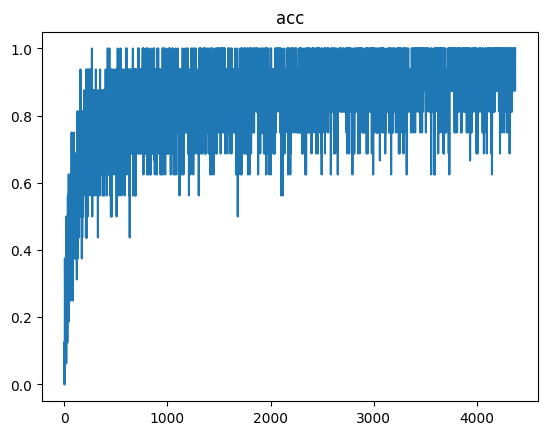

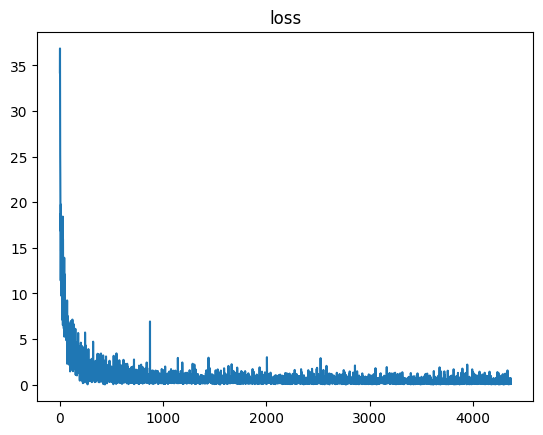

In [29]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(acc_list)
plt.title('acc')

plt.figure()
plt.plot(loss_list)
plt.title('loss')



Paper for reference:
https://arxiv.org/pdf/1710.09435v1.pdf


In [30]:
def fgsm_attack(image, epsilon, data_grad):
    # Collect the element-wise sign of the data gradient
    sign_data_grad = data_grad.sign()

    # Create the perturbed image by adjusting each pixel of the input image
    perturbed_image = image + epsilon * sign_data_grad

    # Return the perturbed image
    return perturbed_image

In [31]:
def test_adversarial( model, device, test_loader, epsilon ):
    # Accuracy counter
    correct = 0
    adv_examples = []
    total = 0

    # Loop over all examples in test set
    for data, target in test_loader:
        # Send the data and label to the device
        data, target = data.type(torch.FloatTensor).to(device), target.to(device)
        data = data.unsqueeze(1) # Match input shape (batch, 1, 256)

        # Set requires_grad attribute of tensor. Important for Attack
        data.requires_grad = True

        # Forward pass the data through the model
        output = model(data)
        init_pred = output.max(1, keepdim=True)[1] # get the index of the max log-probability

        # If the initial prediction is wrong, dont bother attacking, just move on
        if init_pred.item() != target.item():
            total += 1
            continue

        # Calculate the loss
        loss = F.cross_entropy(output, target)

        # Zero all existing gradients
        model.zero_grad()

        # Calculate gradients of model in backward pass
        loss.backward()

        # Collect datagrad
        data_grad = data.grad.data

        # Call FGSM Attack
        perturbed_data = fgsm_attack(data, epsilon, data_grad)

        # Re-classify the perturbed image
        output = model(perturbed_data)

        # Check for success
        final_pred = output.max(1, keepdim=True)[1]

        if final_pred.item() == target.item():
            correct += 1
        else:
            # Save some examples for visualization if the attack worked (fooled the model)
            if len(adv_examples) < 5:
                adv_ex = perturbed_data.squeeze().detach().cpu().numpy()
                orig_ex = data.squeeze().detach().cpu().numpy()
                adv_examples.append( (init_pred.item(), final_pred.item(), orig_ex, adv_ex) )

        total += 1

    # Calculate final accuracy for this epsilon
    final_acc = correct/float(total)
    print(f"Epsilon: {epsilon}\tTest Accuracy = {correct} / {total} = {final_acc}")

    return final_acc, adv_examples

# Run the attack
# Epsilon is the "strength" of the attack. 0.1 is usually distinct enough.
accuracies = []
examples = []
epsilons = [0, .01, .03, .05, .07, .1, .15, .2, .25, .3, .4, .5, .6, .7, .8, .9, 1.0] # Test different attack strengths

print("--- STARTING ADVERSARIAL ATTACK REPORT ---")
for eps in epsilons:
    acc, ex = test_adversarial(model, 'cuda', DataLoader(test_data, batch_size=1, shuffle=False), eps)
    accuracies.append(acc)
    examples.append(ex)

--- STARTING ADVERSARIAL ATTACK REPORT ---
Epsilon: 0	Test Accuracy = 2740 / 2991 = 0.916081578067536
Epsilon: 0.01	Test Accuracy = 2737 / 2991 = 0.9150785690404547
Epsilon: 0.03	Test Accuracy = 2730 / 2991 = 0.9127382146439318
Epsilon: 0.05	Test Accuracy = 2728 / 2991 = 0.912069541959211
Epsilon: 0.07	Test Accuracy = 2723 / 2991 = 0.9103978602474089
Epsilon: 0.1	Test Accuracy = 2717 / 2991 = 0.9083918421932464
Epsilon: 0.15	Test Accuracy = 2701 / 2991 = 0.9030424607154798
Epsilon: 0.2	Test Accuracy = 2693 / 2991 = 0.9003677699765965
Epsilon: 0.25	Test Accuracy = 2673 / 2991 = 0.8936810431293881
Epsilon: 0.3	Test Accuracy = 2648 / 2991 = 0.8853226345703779
Epsilon: 0.4	Test Accuracy = 2633 / 2991 = 0.8803075894349716
Epsilon: 0.5	Test Accuracy = 2605 / 2991 = 0.87094617184888
Epsilon: 0.6	Test Accuracy = 2563 / 2991 = 0.8569040454697425
Epsilon: 0.7	Test Accuracy = 2469 / 2991 = 0.8254764292878636
Epsilon: 0.8	Test Accuracy = 2392 / 2991 = 0.7997325309261116
Epsilon: 0.9	Test Accuracy 

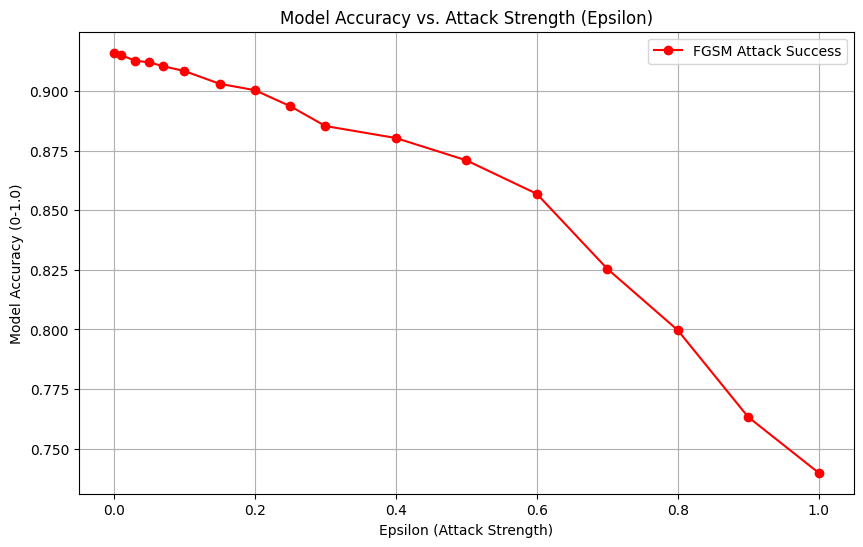

In [32]:
import matplotlib.pyplot as plt

# Check if we have data to plot
if 'epsilons' in locals() and 'accuracies' in locals():
    plt.figure(figsize=(10, 6))

    # Plotting the Epsilon (X-axis) vs Accuracy (Y-axis)
    plt.plot(epsilons, accuracies, "o-", color="red", label="FGSM Attack Success")

    # Labeling the chart
    plt.title("Model Accuracy vs. Attack Strength (Epsilon)")
    plt.xlabel("Epsilon (Attack Strength)")
    plt.ylabel("Model Accuracy (0-1.0)")

    # Adding a grid for easier reading
    plt.grid(True)
    plt.legend()

    # Show the plot
    plt.show()
else:
    print("Please run the 'test_adversarial' loop first to generate the data.")

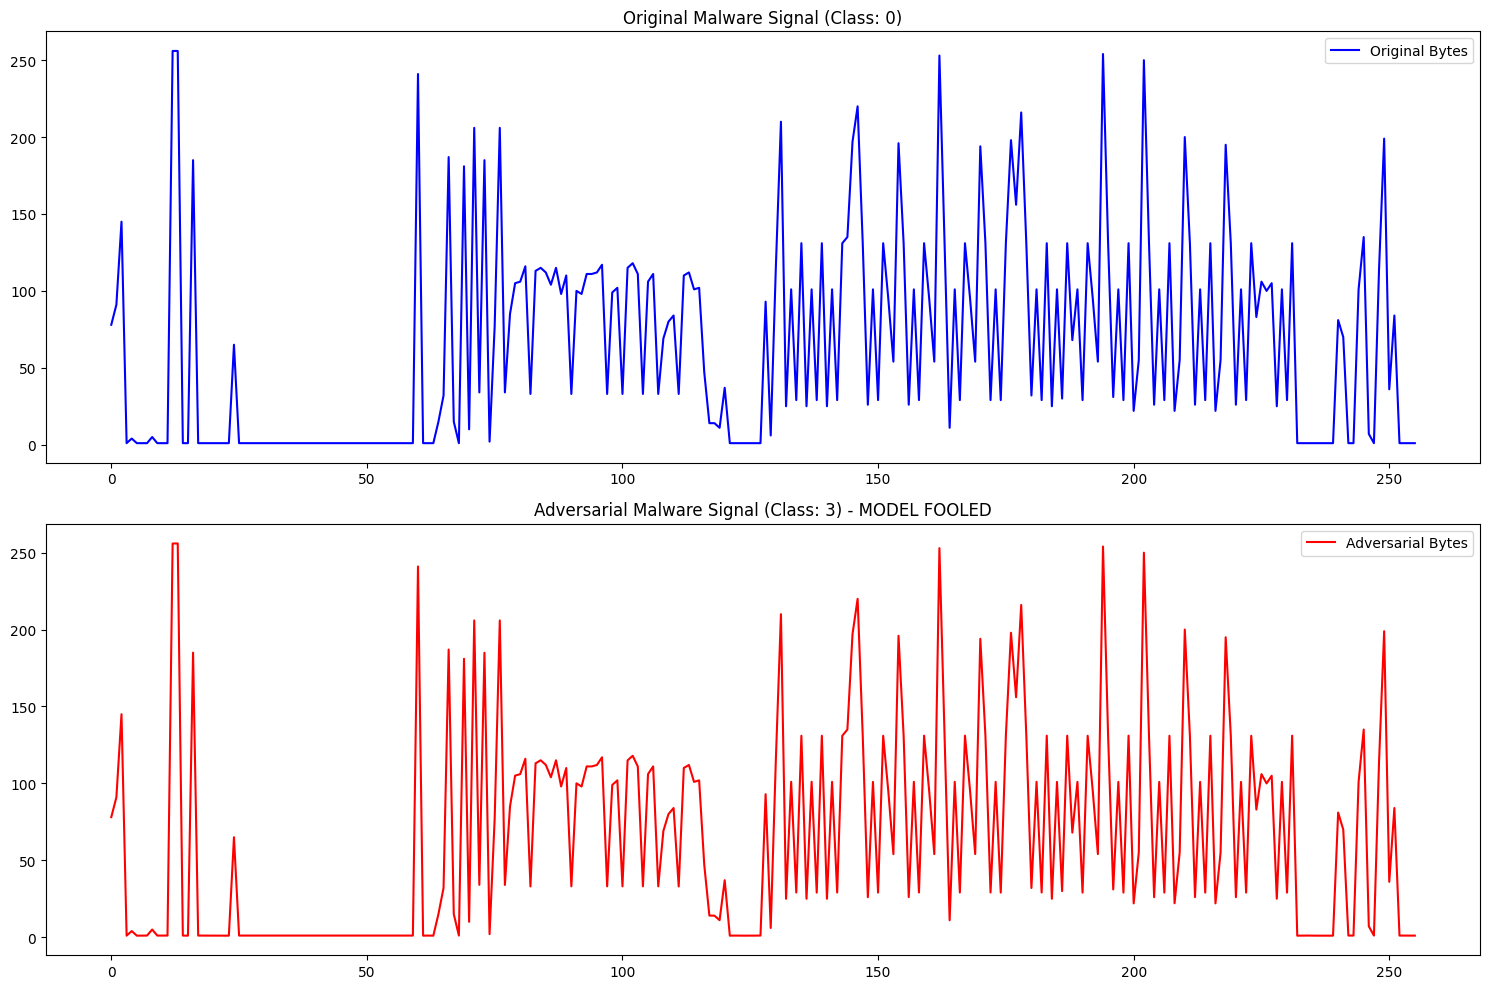

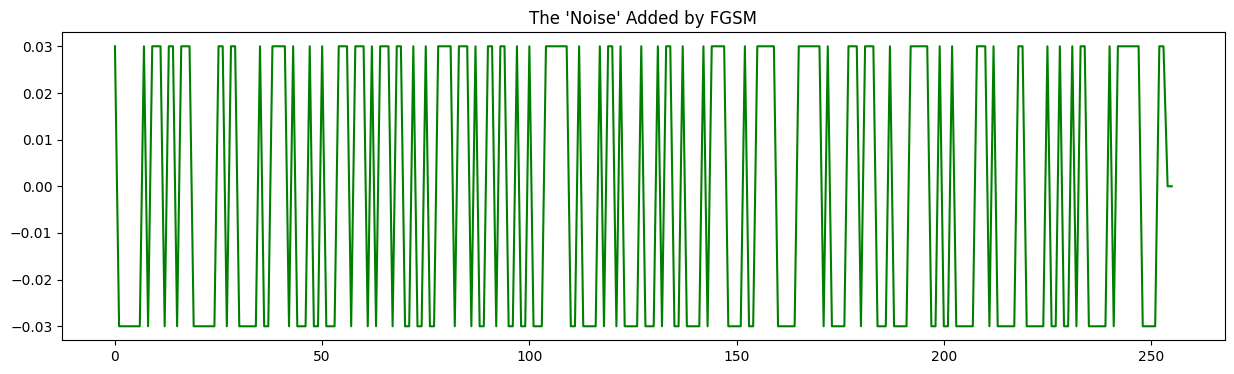

In [33]:
# Plotting the visualization
cnt = 0
plt.figure(figsize=(15,10))

# Plotting the first successful attack from the epsilon=0.1 run
# examples[2] corresponds to epsilon .1 (0, .05, .1)
if len(examples[2]) > 0:
    orig_label, adv_label, orig_data, adv_data = examples[2][0]

    # Plot Original
    plt.subplot(2, 1, 1)
    plt.title(f"Original Malware Signal (Class: {orig_label})")
    plt.plot(orig_data, color="blue", label="Original Bytes")
    plt.legend()

    # Plot Adversarial
    plt.subplot(2, 1, 2)
    plt.title(f"Adversarial Malware Signal (Class: {adv_label}) - MODEL FOOLED")
    plt.plot(adv_data, color="red", label="Adversarial Bytes")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Plot the difference (The Noise)
    plt.figure(figsize=(15,4))
    plt.title("The 'Noise' Added by FGSM")
    plt.plot(adv_data - orig_data, color="green")
    plt.show()
else:
    print("No successful adversarial examples found to plot.")